<a href="https://colab.research.google.com/github/HST0077/HYOTC/blob/main/RN_derivatives_and_Girsanov.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sympy import Symbol, exp, I, stats, simplify, oo

# 1. 기호 변수 정의
# mu: 평균, sigma: 표준편차 (양수 조건 추가)
# u: 특성함수의 매개변수, x: 확률변수값
mu = Symbol('mu', real=True)
sigma = Symbol('sigma', font_variant='italic', positive=True)
u = Symbol('u', real=True)
x = Symbol('x', real=True)

# 2. 정규분포 확률변수 X 정의: X ~ N(mu, sigma^2)
X = stats.Normal('X', mu, sigma)

# 3. density 출력
f=lambda x:stats.density(X)(x)
f(x)

sqrt(2)*exp(-(-mu + x)**2/(2*sigma**2))/(2*sqrt(pi)*sigma)

In [ ]:
from sympy import integrate
integrate(exp(I*u*x)*f(x),(x,-oo,oo))

(2 - erfc(sqrt(2)*I*sigma*u/2))*exp(-sigma**2*u**2/2)*exp(I*mu*u)/2 + exp(-sigma**2*u**2/2)*exp(I*mu*u)*erfc(sqrt(2)*I*sigma*u/2)/2

In [ ]:
_.simplify()

exp(u*(I*mu - sigma**2*u/2))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_L(T=1.0, N=2000, M=50000, a_func=None, seed=111):

    # 1. 기본값 및 시간축 설정
    if a_func is None:
        # 기본값: 시간에 따라 증가하는 함수
        a_func = lambda t: 0.5 + 0.6 * t

    dt = T / N
    t = np.linspace(0, T, N + 1)
    t_eval = t[:-1]  # 각 구간의 시작점 (N개)

    # 2. 계수 a(t) 계산 및 차원 보정 (상수 입력 에러 방지)
    a_vals = np.asarray(a_func(t_eval))
    if a_vals.ndim == 0:
        a_vals = np.full(t_eval.shape, a_vals.item())

    # 3. P-측도 하에서 표준 브라운 운동 증분 생성
    rng = np.random.default_rng(seed=seed)
    dW_P = rng.standard_normal((M, N)) * np.sqrt(dt)

    # 4. 지수 마팅게일 L_t 계산 (Vectorized Operation)

    # (A) Stochastic Integral: integral(a_s dW_s)
    stoch_inc = a_vals[None, :] * dW_P
    stochastic_integral = np.cumsum(stoch_inc, axis=1)
    stochastic_integral = np.insert(stochastic_integral, 0, 0, axis=1)  # t=0 시점 0 추가

    # (B) Quadratic Variation Integral: integral(a_s^2 ds)
    qv_inc = (a_vals**2) * dt
    qv_integral = np.cumsum(qv_inc)
    qv_integral = np.insert(qv_integral, 0, 0)  # t=0 시점 0 추가

    # (C) 최종 L_t 계산: L_t = exp( - (A) - 0.5 * (B) )
    # qv_integral[None, :]를 통해 모든 시나리오 행(M)에 동일한 시간별 QV 적용
    log_L = -stochastic_integral - 0.5 * qv_integral[None, :]
    L = np.exp(log_L)

    # 5. 통계 요약 (평균 계산)
    mean_L = np.mean(L, axis=0)

    # 6. 시각화
    plt.figure(figsize=(10, 6))
    plt.plot(t, mean_L, label='Simulated $E^P[L_t]$ (Monte Carlo)', color='royalblue', lw=1.5)
    plt.axhline(1.0, color='red', linestyle='--', label='Theoretical Value (1.0)', lw=2)

    # 그래프 꾸미기
    plt.title(f'Martingale Property of Girsanov Density\n(M={M}, T={T}, N={N})', fontsize=13)
    plt.xlabel('Time (t)', fontsize=11)
    plt.ylabel('Expectation $E[L_t]$', fontsize=11)
    plt.ylim(0.95, 1.05)  # 마팅게일 성질을 자세히 보기 위해 Y축 범위 제한
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return t, L


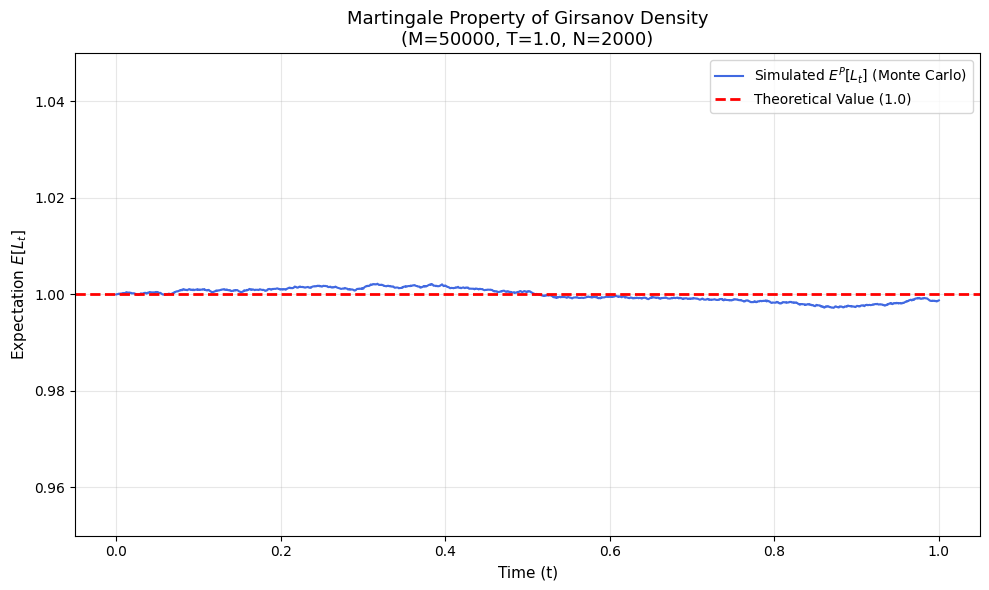

(array([0.000e+00, 5.000e-04, 1.000e-03, ..., 9.990e-01, 9.995e-01,
        1.000e+00]),
 array([[1.        , 1.00338046, 1.01276957, ..., 0.69939962, 0.70119277,
         0.694665  ],
        [1.        , 0.9900872 , 1.00613327, ..., 1.13575958, 1.14704998,
         1.16297478],
        [1.        , 0.99277529, 0.99136523, ..., 1.6082095 , 1.59314286,
         1.58695418],
        ...,
        [1.        , 1.0118466 , 0.99494209, ..., 1.10123446, 1.09741575,
         1.08511342],
        [1.        , 1.01374699, 1.00773   , ..., 1.1981312 , 1.19769576,
         1.19231716],
        [1.        , 1.00466432, 0.98291372, ..., 1.24085627, 1.22657134,
         1.23209477]]))

In [ ]:
#상수 함수
simulate_L(a_func=lambda t: 0.5)

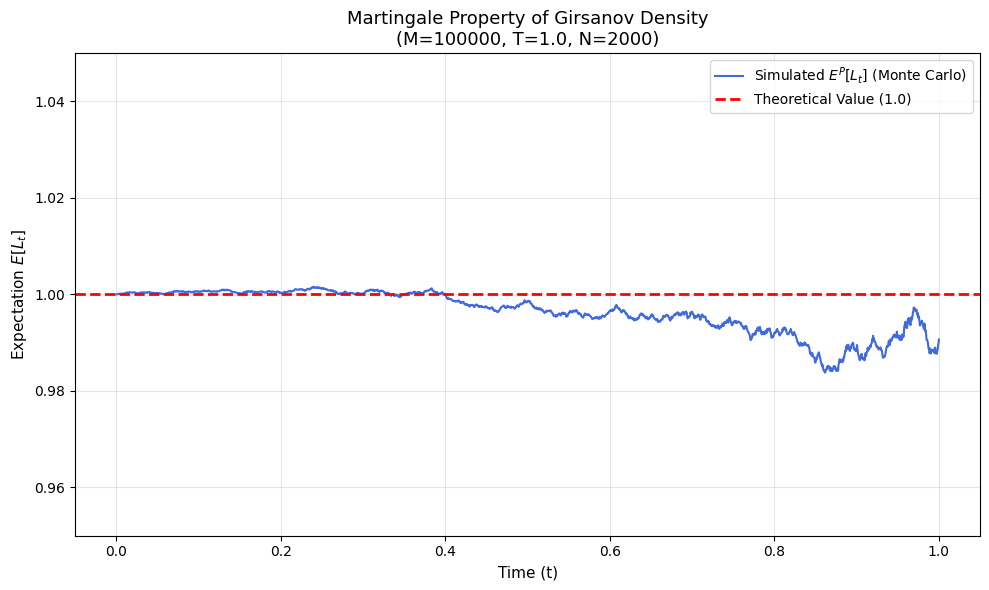

(array([0.000e+00, 5.000e-04, 1.000e-03, ..., 9.990e-01, 9.995e-01,
        1.000e+00]),
 array([[1.        , 1.00338046, 1.01278831, ..., 0.35336037, 0.35746349,
         0.34071196],
        [1.        , 0.9900872 , 1.00616549, ..., 1.68419823, 1.76731428,
         1.89103347],
        [1.        , 0.99277529, 0.99136228, ..., 1.82138469, 1.73554801,
         1.69998846],
        ...,
        [1.        , 1.00031878, 0.9997744 , ..., 0.17737145, 0.18457644,
         0.16785845],
        [1.        , 0.97584162, 0.99056754, ..., 0.05126183, 0.05515696,
         0.05567619],
        [1.        , 1.01083338, 1.02793558, ..., 0.52619775, 0.53394565,
         0.58860372]]))

In [ ]:
#  가변 함수
simulate_L(M=100000,a_func=lambda t: 0.5+2*t)

# **Plain Vanilla Formula**

In [1]:
from math import log, sqrt, pi, exp
from scipy.stats import norm
import numpy as np

def d1(S, K, T, r, sigma):
    return (log(S / K) + (r + sigma ** 2 / 2) * T) / (sigma * sqrt(T))

def d2(S, K, T, r, sigma):
    return d1(S, K, T, r, sigma) - sigma * sqrt(T)

def bs_call(S, K, T, r, sigma):
    return S * norm.cdf(d1(S, K, T, r, sigma)) - K * exp(-r * T) * norm.cdf(d2(S, K, T, r, sigma))

def call_delta(S, K, T, r, sigma):
    return norm.cdf(d1(S, K, T, r, sigma))

def call_gamma(S, K, T, r, sigma):
    return norm.pdf(d1(S, K, T, r, sigma)) / (S * sigma * sqrt(T))

def call_vega(S, K, T, r, sigma): # 1% 변동성 민감도
    return 0.01 * (S * norm.pdf(d1(S, K, T, r, sigma)) * sqrt(T))

def call_theta(S, K, T, r, sigma): # 1 day 감소에 대한 민감도
    return (1/365) * (- (S * norm.pdf(d1(S, K, T, r, sigma)) * sigma) / (2 * sqrt(T)) \
                   - r * K * exp(-r * T) * norm.cdf(d2(S, K, T, r, sigma)))

def call_rho(S, K, T, r, sigma): # 1bp 변화에 대한 민감도
    return 0.0001 * ((K * T * exp(-r * T) * norm.cdf(d2(S, K, T, r, sigma))))

def bs_put(S, K, T, r, sigma):
    return K * exp(-r * T) - S + bs_call(S, K, T, r, sigma)

def put_delta(S, K, T, r, sigma):
    return -norm.cdf(-d1(S, K, T, r, sigma))

def put_gamma(S, K, T, r, sigma):
    return norm.pdf(d1(S, K, T, r, sigma)) / (S * sigma * sqrt(T))

def put_vega(S, K, T, r, sigma): # 1% 변동성 민감도
    return 0.01 * (S * norm.pdf(d1(S, K, T, r, sigma)) * sqrt(T))

def put_theta(S, K, T, r, sigma):  # 1 day 감소에 대한 민감도
    return (1/365) * (
        - (S * norm.pdf(d1(S, K, T, r, sigma)) * sigma) / (2 * np.sqrt(T))
        + r * K * np.exp(-r * T) * norm.cdf(-d2(S, K, T, r, sigma)))

def put_rho(S, K, T, r, sigma):
    return -0.0001 * (K * T * exp(-r * T) * norm.cdf(-d2(S, K, T, r, sigma)))

In [2]:
print('콜옵션의 현재가:',bs_call(100,100,1,0.05,0.3))
print('콜옵션의 델타:',call_delta(100,100,1,0.05,0.3))
print('콜옵션의 감마:',call_gamma(100,100,1,0.05,0.3))
print('콜옵션의 1% 베가:',call_vega(100,100,1,0.05,0.3))
print('콜옵션의 1day 세타:',call_theta(100,100,1,0.05,0.3))
print('콜옵션의 1bp 르호:',call_rho(100,100,1,0.05,0.3))

콜옵션의 현재가: 14.231254785985819
콜옵션의 델타: 0.6242517279060125
콜옵션의 감마: 0.012647764437231512
콜옵션의 1% 베가: 0.3794329331169454
콜옵션의 1day 세타: -0.0221950408136574
콜옵션의 1bp 르호: 0.004819391800461543


# **Quanto Plain Vanilla**

In [12]:
from math import exp, log, sqrt
from scipy.stats import norm


def _d1_d2_spot(S, K, T, sigma, drift_like):
    """lognormal with drift_like in d1 numerator: ln(S/K)+(drift_like+0.5*sigma^2)T."""
    if T <= 0:
        return 0.0, 0.0
    v = sigma * sqrt(T)
    d1 = (log(S / K) + (drift_like + 0.5 * sigma * sigma) * T) / v
    d2 = d1 - v
    return d1, d2


def _q_eff(r_d, r_f, q, rho_s_fx, sigma_s, sigma_fx):
    # q_eff = r_d - r_f + q + ρ σ_S σ_X
    return (r_d - r_f) + q + rho_s_fx * sigma_s * sigma_fx


def _d1_d2(S, K, T, r, q_adj, sigma):
    if T <= 0:
        return 0.0, 0.0
    sqrtT = sqrt(T)
    d1 = (log(S / K) + (r - q_adj + 0.5 * sigma * sigma) * T) / (sigma * sqrtT)
    d2 = d1 - sigma * sqrtT
    return d1, d2

def BSM_Quanto(S, K, T, r_krw, r_f, q, sigma_s, sigma_fx, rho_s_fx, option="call"):
    """
    Quanto 조정(q_adj)을 적용한 유럽형 vanilla 옵션 해석 가격.

    이미지 공식의 quanto drift를 반영한 유럽형 vanilla 옵션 해석 가격.

    - r_krw: domestic rate (= r_d)
    - r_f: foreign risk-free rate
    - q: dividend yield on underlying
    - option: "call" | "put"
    """
    opt = option.lower().strip()
    if opt not in ("call", "put"):
        raise ValueError('option must be "call" or "put"')
    if T <= 0:
        return max(S - K, 0.0) if opt == "call" else max(K - S, 0.0)
    if S <= 0 or K <= 0 or sigma_s <= 0:
        raise ValueError("S, K, sigma_s must be positive")

    q_eff = _q_eff(r_krw, r_f, q, rho_s_fx, sigma_s, sigma_fx)
    d1, d2 = _d1_d2(S, K, T, r_krw, q_eff, sigma_s)
    if opt == "call":
        return S * exp(-q_eff * T) * norm.cdf(d1) - K * exp(-r_krw * T) * norm.cdf(d2)
    return K * exp(-r_krw * T) * norm.cdf(-d2) - S * exp(-q_eff * T) * norm.cdf(-d1)


def BSM_Quanto_Greeks(S, K, T, r_krw, r_f, q, sigma_s, sigma_fx, rho_s_fx, option="call"):
    """
    Quanto vanilla 옵션 해석적 Greeks.
    반환: Price, Delta(Δ), Gamma(Γ), Theta(1day), Vega(1%), Rho(1bp)
    """
    opt = option.lower().strip()
    if opt not in ("call", "put"):
        raise ValueError('option must be "call" or "put"')

    if T <= 0:
        intrinsic = max(S - K, 0.0) if opt == "call" else max(K - S, 0.0)
        delta_int = (1.0 if S > K else 0.0) if opt == "call" else (-1.0 if S < K else 0.0)
        return {
            "Price": float(intrinsic),
            "Delta": float(delta_int),
            "Gamma": 0.0,
            "Theta": 0.0,
            "Vega": 0.0,
            "Rho": 0.0,
        }

    if S <= 0 or K <= 0 or sigma_s <= 0:
        raise ValueError("S, K, sigma_s must be positive")

    q_eff = _q_eff(r_krw, r_f, q, rho_s_fx, sigma_s, sigma_fx)
    d1, d2 = _d1_d2(S, K, T, r_krw, q_eff, sigma_s)
    sqrtT = sqrt(T)
    n_d1 = norm.pdf(d1)

    price = BSM_Quanto(S, K, T, r_krw, r_f, q, sigma_s, sigma_fx, rho_s_fx, opt)

    if opt == "call":
        Delta = exp(-q_eff * T) * norm.cdf(d1)
    else:
        Delta = -exp(-q_eff * T) * norm.cdf(-d1)

    Gamma = exp(-q_eff * T) * n_d1 / (S * sigma_s * sqrtT) if sqrtT > 0 and sigma_s > 0 else 0.0
    Vega = 0.01 * S * exp(-q_eff * T) * sqrtT * n_d1

    # Rho (1bp): bump r_krw
    dr = 0.0001
    price_up = BSM_Quanto(S, K, T, r_krw + dr, r_f, q, sigma_s, sigma_fx, rho_s_fx, opt)
    Rho = float(price_up - price)

    # Theta (1day): consistent with Plain/BSM.py convention
    eps_t = 1.0 / 365.0
    T_eps = max(T - eps_t, 1e-10)
    Theta = BSM_Quanto(S, K, T_eps, r_krw, r_f, q, sigma_s, sigma_fx, rho_s_fx, opt) - price

    return {
        "Price": float(price),
        "Delta": float(Delta),
        "Gamma": float(Gamma),
        "Theta": float(Theta),
        "Vega": float(Vega),
        "Rho": float(Rho),
    }

In [15]:
S0 = 100
K = 100
T = 1.0
q = 0
rd = 0.05
rf = 0.035
sigma_s = 0.30
sigma_x = 0.10
rho = 0.3

call_price= BSM_Quanto(S0, K, T, rd, rf, q, sigma_s, sigma_x, rho, option="call")
print(f"콴토 콜옵션 가격 (단위 가치): {call_price:.4f}")
print(f"1억 원 명목금액 기준 가치: {100000000 * (call_price/S0):,.0f} 원")

콴토 콜옵션 가격 (단위 가치): 12.7870
1억 원 명목금액 기준 가치: 12,787,019 원


In [13]:
BSM_Quanto_Greeks(S0, K, T, rd, rf, q, sigma_s, sigma_x, rho, option="call")

{'Price': 12.78701877783196,
 'Delta': 0.5794668673335579,
 'Gamma': 0.012624177298460538,
 'Theta': -0.017952829308597984,
 'Vega': 0.3787253189538161,
 'Rho': -0.0012786379448215257}

# **일반적 1 star stepdown**

In [20]:
# backend.py 내용
_XP = None
_CAPABILITY = None
def init_backend():
    global _XP, _CAPABILITY
    if _XP is not None:
        return _XP
    try:
        import cupy as cp
        _ = cp.array(1.0) + 1
        _XP = cp
        _CAPABILITY = "gpu"
    except Exception:
        import numpy as np
        _XP = np
        _CAPABILITY = "cpu"
    return _XP
def get_backend():
    global _XP, _CAPABILITY
    if _XP is None:
        init_backend()
    return _XP
def _to_float(x):
    if hasattr(x, "get"):
        return float(x.get())
    return float(x)

In [17]:
"""
SD_1star (1자산) StepDown ELS Monte Carlo
backend.get_backend() 기반으로 GPU/CPU 자동 선택

- SD_1star_MC: 통합 함수 (CRN 지원 포함)
- SD_1star_MC_CPU, SD_lstar_GPU_CRN: 하위호환용 별칭
- MC_Greeks_SD1_GPU_CRN: CRN Greeks (SD_1star_MC 기반)
"""

import numpy as np


def SD_1star_MC(
    S0, kijun, K, T, c, r, q, sigma, barrier, dummy,
    sim, seed=111, antithetic=True,
    Z=None, return_Z=False,
    notional=10000.0, dtype="float64"
):
    """
    SD_1star (1자산) StepDown ELS Monte Carlo (GPU/CPU 통합)

    상품 구조:
    - R = S / kijun (기준가 대비 주가 비율)
    - 조기상환: T[i]일에 R >= K[i] 이면 notional*(1+c[i]) 지급
    - 만기: min(R) < barrier 이면 낙인 → notional*R_T, else notional*(1+dummy)

    Parameters
    ----------
    Z : array or None
        None이면 내부에서 표준정규 Z 생성 (seed/antithetic 적용)
        Z shape: (N, sim) where N = T[-1]
        Z를 넘기면 해당 Z 사용 (CRN). backend와 동일한 라이브러리여야 함.
    return_Z : bool
        True이면 (mu, Z) 반환

    Returns
    -------
    mu : float
    (mu, Z) if return_Z=True
    """
    xp = get_backend()
    dtype_xp = xp.float64 if dtype == "float64" else xp.float32

    T_np = np.atleast_1d(np.asarray(T, dtype=int))
    K_np = np.atleast_1d(np.asarray(K, dtype=float))
    c_np = np.atleast_1d(np.asarray(c, dtype=float))

    if not (len(K_np) == len(T_np) == len(c_np)):
        raise ValueError("K, T, c 길이 불일치")

    K_arr = xp.asarray(K_np, dtype=dtype_xp)
    c_arr = xp.asarray(c_np, dtype=dtype_xp)

    # ---------- Z 준비 (CRN) ----------
    if Z is None:
        N = int(T_np[-1])
        if N <= 0:
            raise ValueError("T[-1] (만기일)은 양의 정수(일)여야 합니다.")

        xp.random.seed(seed)
        if antithetic:
            half = (sim + 1) // 2
            Z_half = xp.random.standard_normal((N, half))
            Z = xp.concatenate([Z_half, -Z_half], axis=1)[:, :sim]
        else:
            Z = xp.random.standard_normal((N, sim))
    else:
        Z = xp.asarray(Z).astype(dtype_xp, copy=False)
        if not (hasattr(Z, "shape") and len(Z.shape) == 2):
            raise ValueError("Z는 (N, sim) 형태여야 합니다.")
        N, sim_Z = Z.shape
        sim = int(sim_Z)
        if int(T_np[-1]) > N:
            raise ValueError(f"T[-1]={int(T_np[-1])}가 Z의 N={N}보다 큽니다.")

    dt = dtype_xp(1.0 / 365.0)
    drift = (r - q - 0.5 * sigma**2) * dt
    vol = sigma * xp.sqrt(dt)

    lnS = drift + vol * Z
    lnS0 = xp.full((1, sim), xp.log(S0), dtype=dtype_xp)
    lnS = xp.concatenate([lnS0, lnS], axis=0)

    S_path = xp.exp(xp.cumsum(lnS, axis=0))
    R = S_path / kijun

    # ---------- 조기상환 ----------
    Price = xp.zeros(sim, dtype=dtype_xp)
    EN = len(T_np)

    for i in range(EN - 1):
        t = int(T_np[i])
        alive = (Price == 0.0)
        hit = alive & (R[t, :] >= K_arr[i])
        Price = xp.where(
            hit,
            dtype_xp(notional) * (dtype_xp(1.0) + c_arr[i]) * xp.exp(-r * t / 365.0),
            Price
        )

    # ---------- 만기상환 ----------
    alive = (Price == 0.0)
    if xp.any(alive):
        R_alive = R[:, alive]
        ki_hit = (xp.min(R_alive, axis=0) < barrier)

        t_mat = int(T_np[-1])
        payoff_ki = dtype_xp(notional) * R_alive[t_mat, :] * xp.exp(-r * t_mat / 365.0)
        payoff_no = dtype_xp(notional) * (dtype_xp(1.0) + dtype_xp(dummy)) * xp.exp(-r * t_mat / 365.0)

        Price_alive = xp.where(ki_hit, payoff_ki, payoff_no)
        Price[alive] = Price_alive

    mu = _to_float(xp.mean(Price))

    if return_Z:
        return mu, Z
    return mu


# 하위호환용 별칭
SD_1star_MC_CPU = SD_1star_MC
SD_lstar_GPU_CRN = SD_1star_MC


def MC_Greeks_SD1_GPU_CRN(
    S0, kijun, K, T, c, r, q, sigma, barrier, dummy,
    sim, seed=111, antithetic=True,
    notional=10000.0, dtype="float64",
    pricer=None,
    bump_S_frac=0.01,      # eps_base = S0 * bump_S_frac (감마 스무딩용 권장)
    bump_sigma_frac=0.01,  # eps_sigma = sigma * bump_sigma_frac
    bump_r_bp=1,           # 1bp
    gamma_smooth=True,
    gamma_mults=(0.5, 1.0, 2.0, 4.0, 8.0),
    gamma_agg="median",    # "median" | "trimmed_mean"
    gamma_trim=0.25
):
    """
    SD_1star (1자산) StepDown ELS MC Greeks (GPU/CPU 통합)
    SD_1star_MC를 pricer로 사용. CRN으로 수치 미분.
    - 감마: 다점 bump + median/trimmed_mean 스무딩
    """
    if pricer is None:
        pricer = SD_1star_MC

    T = np.atleast_1d(np.asarray(T, dtype=int))

    # ---- 1) CRN용 Z를 1회 생성 + base price ----
    C0, Z = pricer(
        S0, kijun, K, T, c, r, q, sigma, barrier, dummy,
        sim=sim, seed=seed, antithetic=antithetic,
        Z=None, return_Z=True, notional=notional, dtype=dtype
    )

    # ----------------------------
    # 2) Delta / Gamma
    # ----------------------------
    # (A) Delta는 기존 중앙차분 1회
    # 기존 정의 유지:
    eps_S_delta = S0 * sigma * bump_S_frac
    # 감마 전용으로 eps를 다르게 쓰고 싶으면 아래처럼 분리 가능
    # eps_S_delta = S0 * bump_S_frac

    if eps_S_delta == 0:
        eps_S_delta = 1e-12

    Cp = pricer(
        S0 + eps_S_delta, kijun, K, T, c, r, q, sigma, barrier, dummy,
        sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype
    )
    Cm = pricer(
        S0 - eps_S_delta, kijun, K, T, c, r, q, sigma, barrier, dummy,
        sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype
    )

    Delta = (Cp - Cm) / (2.0 * eps_S_delta)

    # (B) Gamma는 스무딩(다점 bump + median/trimmed mean)
    if not gamma_smooth: # 감마 스무딩을 안할거면
        Gamma = (Cp - 2.0 * C0 + Cm) / (eps_S_delta ** 2)
    else: # 감마 스미딩을 할거면
        # 감마용 eps_base는 sigma를 곱하지 않는 게 보통 더 안정적 (추천)
        eps_base = S0 * bump_S_frac
        # 만약 네 기존 정의를 그대로 쓰고 싶으면:
        # eps_base = S0 * sigma * bump_S_frac

        if eps_base == 0:
            eps_base = 1e-12

        gammas = []
        for m in gamma_mults:
            eps = float(eps_base * m)
            if eps == 0:
                continue

            Cp_g = pricer(
                S0 + eps, kijun, K, T, c, r, q, sigma, barrier, dummy,
                sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype
            )
            Cm_g = pricer(
                S0 - eps, kijun, K, T, c, r, q, sigma, barrier, dummy,
                sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype
            )
            gammas.append((Cp_g - 2.0 * C0 + Cm_g) / (eps * eps))

        if len(gammas) == 0:
            Gamma = np.nan
        else:
            gammas = np.asarray(gammas, dtype=float)

            if gamma_agg == "median":
                Gamma = float(np.median(gammas))
            elif gamma_agg == "trimmed_mean":
                # 상/하위 trim 후 평균
                trim = float(gamma_trim)
                trim = max(0.0, min(trim, 0.49))
                g_sorted = np.sort(gammas)
                n = len(g_sorted)
                k = int(np.floor(trim * n))
                core = g_sorted[k:n - k] if (n - 2 * k) >= 1 else g_sorted
                Gamma = float(np.mean(core))
            else:
                raise ValueError("gamma_agg는 'median' 또는 'trimmed_mean'만 지원합니다.")

    # ----------------------------
    # 3) Vega (1% Vega)
    # ----------------------------
    eps_sig = sigma * bump_sigma_frac
    if eps_sig == 0:
        eps_sig = 1e-12

    Csig_p = pricer(
        S0, kijun, K, T, c, r, q, sigma + eps_sig, barrier, dummy,
        sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype
    )
    Csig_m = pricer(
        S0, kijun, K, T, c, r, q, sigma - eps_sig, barrier, dummy,
        sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype
    )

    Vega = (Csig_p - Csig_m) / (2.0 * eps_sig)
    Vega_1pct = 0.01 * Vega

    # ----------------------------
    # 4) Theta (1-day): 모든 날짜를 1일 당김
    # ----------------------------
    Tm = np.maximum(T - 1, 0)

    Ct = pricer(
        S0, kijun, K, Tm, c, r, q, sigma, barrier, dummy,
        sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype
    )
    Theta_1d = Ct - C0

    # ----------------------------
    # 5) Rho (1bp)
    # ----------------------------
    eps_r = bump_r_bp * 0.0001

    Cr_p = pricer(
        S0, kijun, K, T, c, r + eps_r, q, sigma, barrier, dummy,
        sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype
    )
    Cr_m = pricer(
        S0, kijun, K, T, c, r - eps_r, q, sigma, barrier, dummy,
        sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype
    )

    Rho_per_unit = (Cr_p - Cr_m) / (2.0 * eps_r)
    Rho_1bp = 0.0001 * Rho_per_unit

    return {
        "Price": C0,
        "Delta": Delta,
        "Gamma": Gamma,
        "Vega(1%)": Vega_1pct,
        "Theta(1d)": Theta_1d,
        "Rho(1bp)": Rho_1bp,
        "bump": {
            "eps_S_delta": eps_S_delta,
            "eps_S_gamma_base": (S0 * bump_S_frac) if gamma_smooth else eps_S_delta,
            # 위 줄에서 eps_base 정의를 sigma 포함으로 바꾸면 같이 바꿔주면 됨
            "eps_sigma": eps_sig,
            "eps_r": eps_r,
            "CRN": True,
            "antithetic": antithetic,
            "seed": seed,
            "gamma_smooth": gamma_smooth,
            "gamma_mults": tuple(gamma_mults),
            "gamma_agg": gamma_agg,
        }
    }


# 하위호환
MC_Greeks_SD1_CRN = MC_Greeks_SD1_GPU_CRN

In [30]:
# 스텝다운 상품 평가 정보
S0=100
kijun=100
r=0.035
q=0
sigma, barrier, dummy, sim=0.3, 0.65, 0.132,10000
K=[0.95,0.95,0.95,0.90,0.90,0.85]
T=np.array([ 181,  365,  546,  730,  912, 1098])
c=np.array([1,2,3,4,5,6])*0.022


MC_Greeks_SD1_GPU_CRN(S0, kijun, K, T, c, r, q, sigma, barrier, dummy, sim)

{'Price': 9225.238046654908,
 'Delta': 37.77149961032895,
 'Gamma': -2.2808161820516943,
 'Vega(1%)': -40.39697969035539,
 'Theta(1d)': 4.662893648457612,
 'Rho(1bp)': -0.6484288828787612,
 'bump': {'eps_S_delta': 0.3,
  'eps_S_gamma_base': 1.0,
  'eps_sigma': 0.003,
  'eps_r': 0.0001,
  'CRN': True,
  'antithetic': True,
  'seed': 111,
  'gamma_smooth': True,
  'gamma_mults': (0.5, 1.0, 2.0, 4.0, 8.0),
  'gamma_agg': 'median'}}

# **Quanto 1 star Step Down**

In [27]:
"""
SD_1star (1자산) StepDown ELS Monte Carlo — Quanto adjusted

SD_1star_MC.py와 동일한 상품 구조·CRN(Z) 규칙.
차이점: 해외지수 등 KRW 발행 시 drift에 quanto 보정을 반영.

이미지/BSM_Quanto.py와 동일한 quanto drift(국내측도):

    μ_q = r_f - q - I * rho_s_fx * sigma * sigma_fx
    일일 drift = (μ_q - 0.5 * sigma^2) * dt

할인(현가)은 domestic rate r(=KRW 무위험)로 동일.

- r: KRW 무위험 이자율 (할인에도 동일 사용)
- r_f: 해외 무위험 이자율 (quanto drift에 사용). None이면 r_f=r로 처리(하위호환)
- sigma_fx: 지수 통화 / KRW FX 변동성
- rho_s_fx: Corr(dW_S, dW_FX)
- quanto_on=False 이면 μ_q = r_f - q 로 처리 (ρ-term 제거)

- SD_1star_MC_quanto: 통합 pricer (Z 외부 주입 CRN 지원)
- SD_1star_MC_batch_quanto: 복수 S0 일괄
- MC_Greeks_SD1_Quanto / MC_Greeks_SD1_Quanto_GPU_CRN: CRN Greeks
"""

def SD_1star_MC_quanto(
    S0,
    kijun,
    K,
    T,
    c,
    r,
    q,
    sigma,
    barrier,
    dummy,
    sim,
    seed=111,
    antithetic=True,
    Z=None,
    return_Z=False,
    notional=10000.0,
    dtype="float64",
    sigma_fx=0.0,
    rho_s_fx=0.0,
    r_f=None,
    quanto_on=True,
):
    """
    SD_1star (1자산) StepDown ELS Monte Carlo with quanto drift adjustment.

    상품 구조는 SD_1star_MC와 동일:
    - R = S / kijun
    - 조기상환: T[i]일에 R >= K[i] → notional*(1+c[i]) 할인 지급
    - 만기: min(R) < barrier → 낙인, else notional*(1+dummy)
    """
    xp = get_backend()
    dtype_xp = xp.float64 if dtype == "float64" else xp.float32

    T_np = np.atleast_1d(np.asarray(T, dtype=int))
    K_np = np.atleast_1d(np.asarray(K, dtype=float))
    c_np = np.atleast_1d(np.asarray(c, dtype=float))

    if not (len(K_np) == len(T_np) == len(c_np)):
        raise ValueError("K, T, c 길이 불일치")

    K_arr = xp.asarray(K_np, dtype=dtype_xp)
    c_arr = xp.asarray(c_np, dtype=dtype_xp)

    sigma_xp = dtype_xp(sigma)
    q_xp = dtype_xp(q)
    r_f_xp = dtype_xp(r if r_f is None else r_f)
    sf = dtype_xp(sigma_fx)
    rsf = dtype_xp(rho_s_fx)
    mu_q = r_f_xp - q_xp - (dtype_xp(1.0) if quanto_on else dtype_xp(0.0)) * rsf * sigma_xp * sf

    # ---------- Z 준비 (CRN) — SD_1star_MC와 동일 ----------
    if Z is None:
        N = int(T_np[-1])
        if N <= 0:
            raise ValueError("T[-1] (만기일)은 양의 정수(일)여야 합니다.")
        xp.random.seed(seed)
        if antithetic:
            half = (sim + 1) // 2
            Z_half = xp.random.standard_normal((N, half))
            Z = xp.concatenate([Z_half, -Z_half], axis=1)[:, :sim]
        else:
            Z = xp.random.standard_normal((N, sim))
    else:
        Z = xp.asarray(Z).astype(dtype_xp, copy=False)
        if not (hasattr(Z, "shape") and len(Z.shape) == 2):
            raise ValueError("Z는 (N, sim) 형태여야 합니다.")
        N, sim_Z = Z.shape
        sim = int(sim_Z)
        if int(T_np[-1]) > N:
            raise ValueError(f"T[-1]={int(T_np[-1])}가 Z의 N={N}보다 큽니다.")

    dt = dtype_xp(1.0 / 365.0)
    drift = (mu_q - 0.5 * sigma_xp**2) * dt
    vol = sigma_xp * xp.sqrt(dt)

    lnS = drift + vol * Z
    lnS0 = xp.full((1, sim), xp.log(dtype_xp(S0)), dtype=dtype_xp)
    lnS = xp.concatenate([lnS0, lnS], axis=0)

    S_path = xp.exp(xp.cumsum(lnS, axis=0))
    R = S_path / dtype_xp(kijun)

    Price = xp.zeros(sim, dtype=dtype_xp)
    EN = len(T_np)
    r_xp = dtype_xp(r)

    for i in range(EN - 1):
        t = int(T_np[i])
        alive = Price == 0.0
        hit = alive & (R[t, :] >= K_arr[i])
        Price = xp.where(
            hit,
            dtype_xp(notional) * (dtype_xp(1.0) + c_arr[i]) * xp.exp(-r_xp * t / 365.0),
            Price,
        )

    alive = Price == 0.0
    if xp.any(alive):
        R_alive = R[:, alive]
        ki_hit = xp.min(R_alive, axis=0) < dtype_xp(barrier)
        t_mat = int(T_np[-1])
        payoff_ki = dtype_xp(notional) * R_alive[t_mat, :] * xp.exp(-r_xp * t_mat / 365.0)
        payoff_no = dtype_xp(notional) * (dtype_xp(1.0) + dtype_xp(dummy)) * xp.exp(-r_xp * t_mat / 365.0)
        Price_alive = xp.where(ki_hit, payoff_ki, payoff_no)
        Price[alive] = Price_alive

    mu = _to_float(xp.mean(Price))
    if return_Z:
        return mu, Z
    return mu


SD_1star_MC_quanto_CPU = SD_1star_MC_quanto
SD_lstar_GPU_CRN_quanto = SD_1star_MC_quanto


def SD_1star_MC_batch_quanto(
    S0_arr,
    kijun,
    K,
    T,
    c,
    r,
    q,
    sigma,
    barrier,
    dummy,
    sim,
    seed=111,
    antithetic=True,
    Z=None,
    notional=10000.0,
    dtype="float64",
    sigma_fx=0.0,
    rho_s_fx=0.0,
    r_f=None,
    quanto_on=True,
):
    """복수 S0 일괄. G 경로 1회 + quanto drift 반영."""
    xp = get_backend()
    dtype_xp = xp.float64 if dtype == "float64" else xp.float32

    T_np = np.atleast_1d(np.asarray(T, dtype=int))
    K_np = np.atleast_1d(np.asarray(K, dtype=float))
    c_np = np.atleast_1d(np.asarray(c, dtype=float))
    if not (len(K_np) == len(T_np) == len(c_np)):
        raise ValueError("K, T, c 길이 불일치")

    K_arr = xp.asarray(K_np, dtype=dtype_xp)
    c_arr = xp.asarray(c_np, dtype=dtype_xp)
    S0_arr = np.atleast_1d(np.asarray(S0_arr, dtype=float))

    sigma_xp = dtype_xp(sigma)
    q_xp = dtype_xp(q)
    r_f_xp = dtype_xp(r if r_f is None else r_f)
    sf = dtype_xp(sigma_fx)
    rsf = dtype_xp(rho_s_fx)
    mu_q = r_f_xp - q_xp - (dtype_xp(1.0) if quanto_on else dtype_xp(0.0)) * rsf * sigma_xp * sf
    r_xp = dtype_xp(r)

    if Z is None:
        N = int(T_np[-1])
        if N <= 0:
            raise ValueError("T[-1] (만기일)은 양의 정수(일)여야 합니다.")
        xp.random.seed(seed)
        if antithetic:
            half = (sim + 1) // 2
            Z_half = xp.random.standard_normal((N, half))
            Z = xp.concatenate([Z_half, -Z_half], axis=1)[:, :sim]
        else:
            Z = xp.random.standard_normal((N, sim))
    else:
        Z = xp.asarray(Z).astype(dtype_xp, copy=False)
        N, sim_Z = Z.shape
        sim = int(sim_Z)
        if int(T_np[-1]) > N:
            raise ValueError(f"T[-1]={int(T_np[-1])}가 Z의 N={N}보다 큽니다.")

    dt = dtype_xp(1.0 / 365.0)
    drift = (mu_q - 0.5 * sigma_xp**2) * dt
    vol = sigma_xp * xp.sqrt(dt)

    daily_ln = drift + vol * Z
    lnG = xp.concatenate([xp.zeros((1, sim), dtype=dtype_xp), daily_ln], axis=0)
    G = xp.exp(xp.cumsum(lnG, axis=0))

    price_arr = np.zeros(len(S0_arr), dtype=float)
    EN = len(T_np)

    for i, S0 in enumerate(S0_arr):
        scale = dtype_xp(S0 / kijun)
        R = scale * G
        Price = xp.zeros(sim, dtype=dtype_xp)

        for j in range(EN - 1):
            t = int(T_np[j])
            alive = Price == 0.0
            hit = alive & (R[t, :] >= K_arr[j])
            Price = xp.where(
                hit,
                dtype_xp(notional) * (dtype_xp(1.0) + c_arr[j]) * xp.exp(-r_xp * t / 365.0),
                Price,
            )

        alive = Price == 0.0
        if xp.any(alive):
            R_alive = R[:, alive]
            ki_hit = xp.min(R_alive, axis=0) < dtype_xp(barrier)
            t_mat = int(T_np[-1])
            payoff_ki = dtype_xp(notional) * R_alive[t_mat, :] * xp.exp(-r_xp * t_mat / 365.0)
            payoff_no = dtype_xp(notional) * (dtype_xp(1.0) + dtype_xp(dummy)) * xp.exp(-r_xp * t_mat / 365.0)
            Price_alive = xp.where(ki_hit, payoff_ki, payoff_no)
            Price[alive] = Price_alive

        price_arr[i] = _to_float(xp.mean(Price))

    return price_arr


def MC_Greeks_SD1_Quanto(
    S0,
    kijun,
    K,
    T,
    c,
    r,
    q,
    sigma,
    barrier,
    dummy,
    sim,
    seed=111,
    antithetic=True,
    notional=10000.0,
    dtype="float64",
    pricer=None,
    bump_S_frac=0.01,
    bump_sigma_frac=0.01,
    bump_r_bp=1,
    sigma_fx=0.0,
    rho_s_fx=0.0,
    r_f=None,
    quanto_on=True,
):
    """Quanto pricer 기반 CRN Greeks (단일 Gamma bump)."""
    if pricer is None:
        pricer = SD_1star_MC_quanto

    T = np.atleast_1d(np.asarray(T, dtype=int))
    q_kw = dict(sigma_fx=sigma_fx, rho_s_fx=rho_s_fx, quanto_on=quanto_on, r_f=r_f)

    C0, Z = pricer(
        S0, kijun, K, T, c, r, q, sigma, barrier, dummy,
        sim=sim, seed=seed, antithetic=antithetic,
        Z=None, return_Z=True, notional=notional, dtype=dtype, **q_kw
    )

    eps_S = max(S0 * sigma * bump_S_frac, 1e-12)
    Cp = pricer(S0 + eps_S, kijun, K, T, c, r, q, sigma, barrier, dummy,
                sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype, **q_kw)
    Cm = pricer(S0 - eps_S, kijun, K, T, c, r, q, sigma, barrier, dummy,
                sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype, **q_kw)
    Delta = (Cp - Cm) / (2.0 * eps_S)
    Gamma = (Cp - 2.0 * C0 + Cm) / (eps_S**2)

    eps_sig = max(sigma * bump_sigma_frac, 1e-12)
    Csig_p = pricer(S0, kijun, K, T, c, r, q, sigma + eps_sig, barrier, dummy,
                    sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype, **q_kw)
    Csig_m = pricer(S0, kijun, K, T, c, r, q, max(sigma - eps_sig, 1e-8), barrier, dummy,
                    sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype, **q_kw)
    Vega_1pct = 0.01 * (Csig_p - Csig_m) / (2.0 * eps_sig)

    Tm = np.maximum(T - 1, 0)
    Ct = pricer(S0, kijun, K, Tm, c, r, q, sigma, barrier, dummy,
                sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype, **q_kw)
    Theta_1d = Ct - C0

    eps_r = bump_r_bp * 0.0001
    Cr_p = pricer(S0, kijun, K, T, c, r + eps_r, q, sigma, barrier, dummy,
                  sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype, **q_kw)
    Cr_m = pricer(S0, kijun, K, T, c, r - eps_r, q, sigma, barrier, dummy,
                  sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype, **q_kw)
    Rho_1bp = 0.0001 * (Cr_p - Cr_m) / (2.0 * eps_r)

    return {
        "Price": C0,
        "Delta": Delta,
        "Gamma": Gamma,
        "Vega(1%)": Vega_1pct,
        "Theta(1d)": Theta_1d,
        "Rho(1bp)": Rho_1bp,
    }


def MC_Greeks_SD1_Quanto_GPU_CRN(
    S0,
    kijun,
    K,
    T,
    c,
    r,
    q,
    sigma,
    barrier,
    dummy,
    sim,
    seed=111,
    antithetic=True,
    notional=10000.0,
    dtype="float64",
    pricer=None,
    bump_S_frac=0.01,
    bump_sigma_frac=0.01,
    bump_r_bp=1,
    gamma_smooth=True,
    gamma_mults=(0.5, 1.0, 2.0, 4.0, 8.0),
    gamma_agg="median",
    gamma_trim=0.25,
    sigma_fx=0.0,
    rho_s_fx=0.0,
    r_f=None,
    quanto_on=True,
):
    """Quanto pricer + Gamma 다점 스무딩."""
    if pricer is None:
        pricer = SD_1star_MC_quanto

    T = np.atleast_1d(np.asarray(T, dtype=int))
    q_kw = dict(sigma_fx=sigma_fx, rho_s_fx=rho_s_fx, quanto_on=quanto_on, r_f=r_f)

    C0, Z = pricer(
        S0, kijun, K, T, c, r, q, sigma, barrier, dummy,
        sim=sim, seed=seed, antithetic=antithetic,
        Z=None, return_Z=True, notional=notional, dtype=dtype, **q_kw
    )

    eps_S_delta = max(S0 * sigma * bump_S_frac, 1e-12)
    Cp = pricer(S0 + eps_S_delta, kijun, K, T, c, r, q, sigma, barrier, dummy,
                sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype, **q_kw)
    Cm = pricer(S0 - eps_S_delta, kijun, K, T, c, r, q, sigma, barrier, dummy,
                sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype, **q_kw)
    Delta = (Cp - Cm) / (2.0 * eps_S_delta)

    if not gamma_smooth:
        Gamma = (Cp - 2.0 * C0 + Cm) / (eps_S_delta**2)
    else:
        eps_base = max(S0 * bump_S_frac, 1e-12)
        gammas = []
        for m in gamma_mults:
            eps = float(eps_base * m)
            if eps == 0:
                continue
            Cp_g = pricer(S0 + eps, kijun, K, T, c, r, q, sigma, barrier, dummy,
                          sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype, **q_kw)
            Cm_g = pricer(S0 - eps, kijun, K, T, c, r, q, sigma, barrier, dummy,
                          sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype, **q_kw)
            gammas.append((Cp_g - 2.0 * C0 + Cm_g) / (eps * eps))
        if len(gammas) == 0:
            Gamma = float("nan")
        else:
            gammas = np.asarray(gammas, dtype=float)
            if gamma_agg == "median":
                Gamma = float(np.median(gammas))
            elif gamma_agg == "trimmed_mean":
                trim = max(0.0, min(float(gamma_trim), 0.49))
                g_sorted = np.sort(gammas)
                n = len(g_sorted)
                k = int(np.floor(trim * n))
                core = g_sorted[k : n - k] if (n - 2 * k) >= 1 else g_sorted
                Gamma = float(np.mean(core))
            else:
                raise ValueError("gamma_agg는 'median' 또는 'trimmed_mean'만 지원합니다.")

    eps_sig = max(sigma * bump_sigma_frac, 1e-12)
    Csig_p = pricer(S0, kijun, K, T, c, r, q, sigma + eps_sig, barrier, dummy,
                    sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype, **q_kw)
    Csig_m = pricer(S0, kijun, K, T, c, r, q, sigma - eps_sig, barrier, dummy,
                    sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype, **q_kw)
    Vega_1pct = 0.01 * (Csig_p - Csig_m) / (2.0 * eps_sig)

    Tm = np.maximum(T - 1, 0)
    Ct = pricer(S0, kijun, K, Tm, c, r, q, sigma, barrier, dummy,
                sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype, **q_kw)
    Theta_1d = Ct - C0

    eps_r = bump_r_bp * 0.0001
    Cr_p = pricer(S0, kijun, K, T, c, r + eps_r, q, sigma, barrier, dummy,
                  sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype, **q_kw)
    Cr_m = pricer(S0, kijun, K, T, c, r - eps_r, q, sigma, barrier, dummy,
                  sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype, **q_kw)
    Rho_1bp = 0.0001 * (Cr_p - Cr_m) / (2.0 * eps_r)

    return {
        "Price": C0,
        "Delta": Delta,
        "Gamma": Gamma,
        "Vega(1%)": Vega_1pct,
        "Theta(1d)": Theta_1d,
        "Rho(1bp)": Rho_1bp,
        "bump": {
            "eps_S_delta": eps_S_delta,
            "eps_S_gamma_base": (S0 * bump_S_frac) if gamma_smooth else eps_S_delta,
            "eps_sigma": eps_sig,
            "eps_r": eps_r,
            "CRN": True,
            "antithetic": antithetic,
            "seed": seed,
            "gamma_smooth": gamma_smooth,
            "gamma_mults": tuple(gamma_mults),
            "gamma_agg": gamma_agg,
            "quanto": {"sigma_fx": sigma_fx, "rho_s_fx": rho_s_fx, "quanto_on": quanto_on},
        },
    }


MC_Greeks_SD1_Quanto_CRN = MC_Greeks_SD1_Quanto_GPU_CRN


In [31]:
# 스텝다운 상품 평가 정보
S0=100
kijun=100
r=0.05
r_f=0.035
q=0
sigma, barrier, dummy, sim=0.3, 0.65, 0.132,10000
K=[0.95,0.95,0.95,0.90,0.90,0.85]
T=np.array([ 181,  365,  546,  730,  912, 1098])
c=np.array([1,2,3,4,5,6])*0.022
sigma_fx=0.1
rho_s_fx=0.3

MC_Greeks_SD1_Quanto_GPU_CRN(
    S0,
    kijun,
    K,
    T,
    c,
    r,
    q,
    sigma,
    barrier,
    dummy,
    sim,
    seed=111,
    antithetic=True,
    notional=10000.0,
    dtype="float64",
    pricer=None,
    bump_S_frac=0.01,
    bump_sigma_frac=0.01,
    bump_r_bp=1,
    gamma_smooth=True,
    gamma_mults=(0.5, 1.0, 2.0, 4.0, 8.0),
    gamma_agg="median",
    gamma_trim=0.25,
    sigma_fx=sigma_fx,
    rho_s_fx=rho_s_fx,
    r_f=r_f,
    quanto_on=True,
)

{'Price': 9028.414189287103,
 'Delta': 53.68983719387264,
 'Gamma': -2.768772761129185,
 'Vega(1%)': -45.251708199233086,
 'Theta(1d)': 2.015439978635186,
 'Rho(1bp)': -0.9076665947677611,
 'bump': {'eps_S_delta': 0.3,
  'eps_S_gamma_base': 1.0,
  'eps_sigma': 0.003,
  'eps_r': 0.0001,
  'CRN': True,
  'antithetic': True,
  'seed': 111,
  'gamma_smooth': True,
  'gamma_mults': (0.5, 1.0, 2.0, 4.0, 8.0),
  'gamma_agg': 'median',
  'quanto': {'sigma_fx': 0.1, 'rho_s_fx': 0.3, 'quanto_on': True}}}